# LALSimulation example

In [1]:
%pylab inline
%config InlineBackend.figure_format = 'retina'

Populating the interactive namespace from numpy and matplotlib


In [13]:
import lalsimulation as lalsim
import lal

import seaborn as sns
sns.set_theme(palette='colorblind', font_scale=1.2)

In [28]:
approximant = lalsim.SimInspiralGetApproximantFromString("IMRPhenomD")

# frequency array parameters
df = 0.25
f_min = 20
f_max = 1024
f_ref = f_min

# source parameters
m1_msun = 30
m2_msun = 30
chi1 = [0, 0, 0.5]
chi2 = [0, 0, 0.5]
dist_mpc = 440
inclination = 0
phi_ref = 0

m1_kg = m1_msun*lal.MSUN_SI
m2_kg = m2_msun*lal.MSUN_SI
distance = dist_mpc*1e6*lal.PC_SI

hp, hc = lalsim.SimInspiralChooseFDWaveform(m1_kg, m2_kg,
                                            chi1[0], chi1[1], chi1[2],
                                            chi2[0], chi2[1], chi2[2],
                                            distance, inclination,
                                            phi_ref, 0, 0., 0.,
                                            df, f_min, f_max, f_ref,
                                            None, approximant)

Plot the Fourier amplitude:

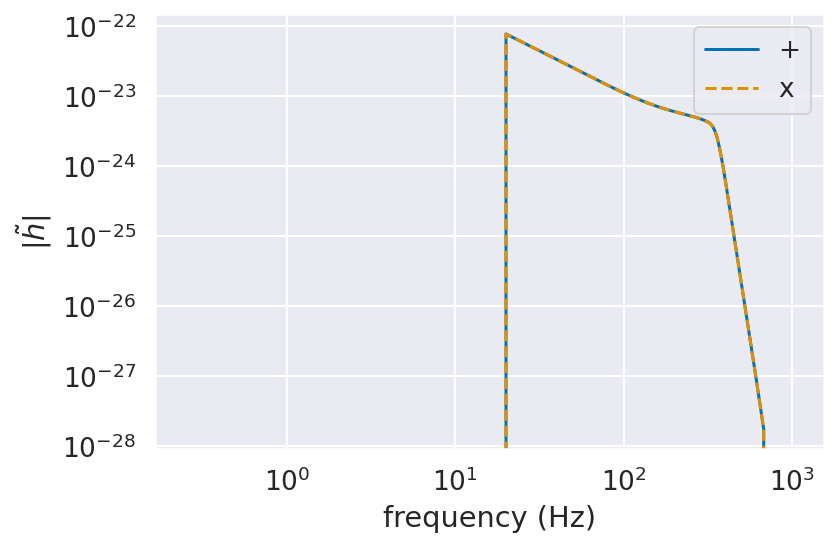

In [29]:
freq = arange(len(hp.data.data))*df
loglog(freq, abs(hp.data.data), label="+")
loglog(freq, abs(hc.data.data), ls='--', label="x")
legend()
xlabel("frequency (Hz)")
ylabel(r"$|\tilde{h}|$");

Plot the Fourier phase:

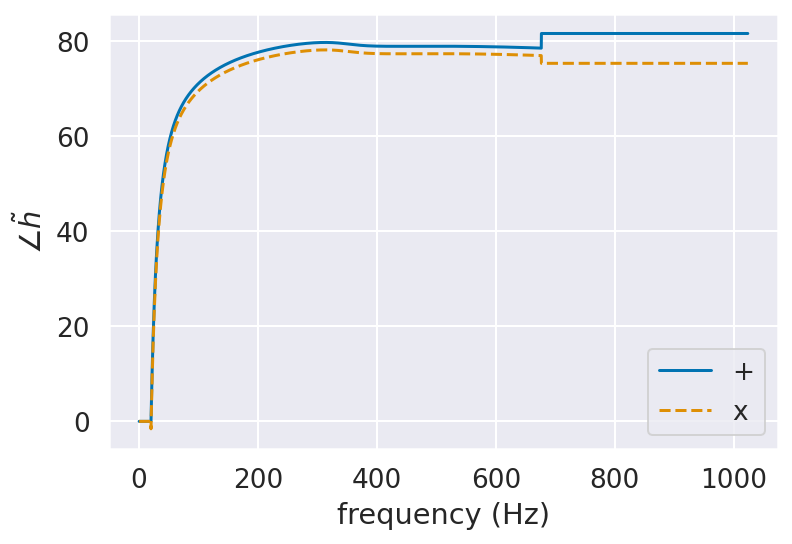

In [30]:
freq = arange(len(hp.data.data))*df
plot(freq, unwrap(angle(hp.data.data)), label="+")
plot(freq, unwrap(angle(hc.data.data)), ls='--', label="x")
legend()
xlabel("frequency (Hz)")
ylabel(r"$\angle \tilde{h}$");

You can easily inverse-Fourier transform the waveform:

In [31]:
hp_td = np.fft.irfft(hp.data.data)

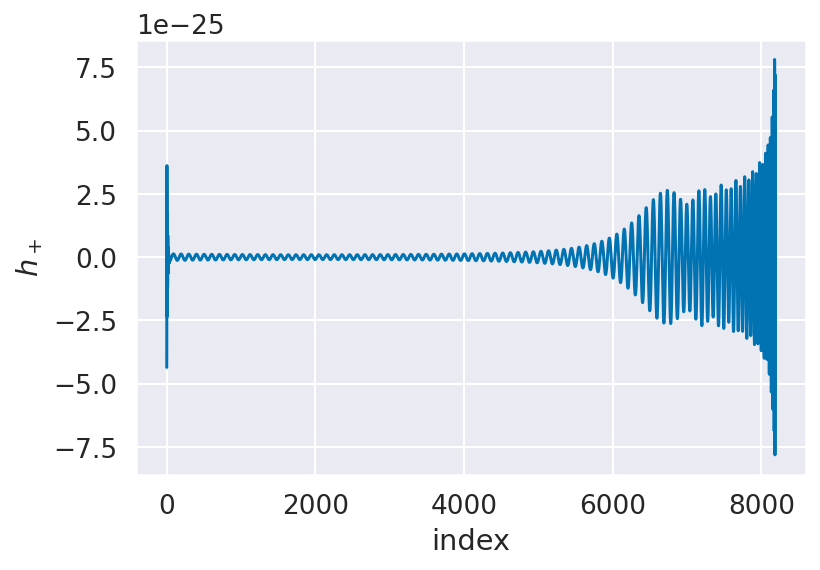

In [35]:
plot(hp_td)
xlabel("index")
ylabel(r"$h_+$");

Note that the "peak" (or whatever `IMRPhenomD` takes to be the reference time) of this waveform was placed at the beggining of the segment.